## Baseline Model Training

## Import Libraries

## Model
    Logistic Regression
    Decision Tree
    Random Forest
    Support Vector Machine
    K-Nearest Neighbors
    Naive Bayes

## For each model report
    Accuracy
    Precision
    Recall
    F1-score
    ROC-AUC
    Confusion Matrix
    Cross-validation score
    Training time
    Prediction time

In [3]:
import pandas as pd

df = pd.read_csv("../data/raw/heart.csv")

X = df.drop("target", axis=1)
y = df["target"]

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# importing libraries

In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import SVC

from sklearn.neighbors import KNeighborsClassifier

from sklearn.naive_bayes import GaussianNB

# Load preprocessed Dataset

In [20]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()

## Creating Models

In [21]:
models = {

    "Logistic Regression":
        LogisticRegression(random_state=42),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(random_state=42),

    "Support Vector Machine":
        SVC(probability=True, random_state=42),

    "KNN":
        KNeighborsClassifier(),

    "Naive Bayes":
        GaussianNB()
}

## Evalution Function

In [22]:
def evaluate_model(model):

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    probability = model.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, prediction)

    precision = precision_score(y_test, prediction)

    recall = recall_score(y_test, prediction)

    f1 = f1_score(y_test, prediction)

    auc = roc_auc_score(y_test, probability)

    cv = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    ).mean()

    return [

        accuracy,

        precision,

        recall,

        f1,

        auc,

        cv
    ]

## To fix the Missing value

In [23]:
from sklearn.impute import SimpleImputer

# Create the imputer (fills missing values with the mean of each column)
imputer = SimpleImputer(strategy='mean')

# Impute X_train and X_test
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)


In [24]:
results = []

for name, model in models.items():

    metrics = evaluate_model(model)

    results.append([name] + metrics)

## Result Table

In [25]:
results_df = pd.DataFrame(

    results,

    columns=[

        "Model",

        "Accuracy",

        "Precision",

        "Recall",

        "F1",

        "ROC_AUC",

        "CV Score"

    ]

)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,CV Score
0,Logistic Regression,0.804348,0.811321,0.843137,0.826923,0.886418,0.815177
1,Decision Tree,0.750000,0.754545,0.813725,0.783019,0.742229,0.735016
2,Random Forest,0.842391,0.828829,0.901961,0.863850,0.921628,0.815205
3,Support Vector Machine,0.809783,0.796460,0.882353,0.837209,0.895146,0.824710
4,KNN,0.798913,0.809524,0.833333,0.821256,0.869799,0.781265
5,Naive Bayes,0.815217,0.820755,0.852941,0.836538,0.873864,0.812493


## checking for best model that will become base model

# here random forest is best accuracy

In [26]:
results_df.sort_values(

    by="Accuracy",

    ascending=False

)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,CV Score
2,Random Forest,0.842391,0.828829,0.901961,0.863850,0.921628,0.815205
5,Naive Bayes,0.815217,0.820755,0.852941,0.836538,0.873864,0.812493
3,Support Vector Machine,0.809783,0.796460,0.882353,0.837209,0.895146,0.824710
0,Logistic Regression,0.804348,0.811321,0.843137,0.826923,0.886418,0.815177
4,KNN,0.798913,0.809524,0.833333,0.821256,0.869799,0.781265
1,Decision Tree,0.750000,0.754545,0.813725,0.783019,0.742229,0.735016


## Now checking for Confustion Matrix

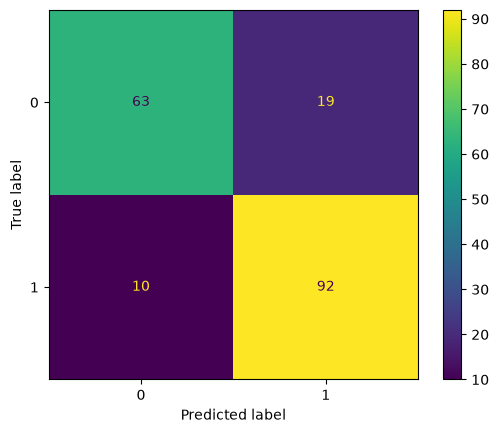

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay

best_model = RandomForestClassifier(random_state=42)

best_model.fit(X_train, y_train)

ConfusionMatrixDisplay.from_estimator(

    best_model,

    X_test,

    y_test

)

## Now for Classification Report

In [31]:
prediction = best_model.predict(X_test)

print(

    classification_report(

    y_test,

    prediction

    )

)

              precision    recall  f1-score   support

           0       0.86      0.77      0.81        82
           1       0.83      0.90      0.86       102

    accuracy                           0.84       184
   macro avg       0.85      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



## ROC Curve

# Higher ROC-AUC generally indicates better discrimination between classes.

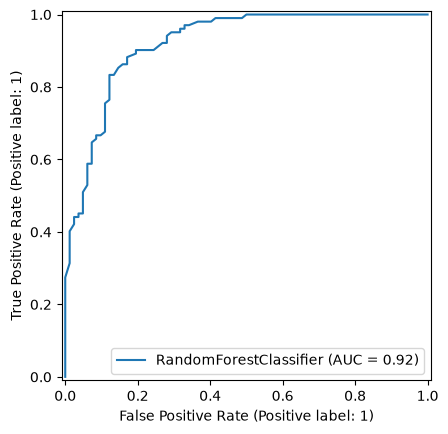

In [32]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(

    best_model,

    X_test,

    y_test

)

## Save Best Model

In [33]:
import joblib

joblib.dump(

best_model,

"../models/random_forest.pkl"

)

['../models/random_forest.pkl']